# BIA 652 Final Project — Motor Vehicle Insurance Premium & Claims Prediction
**Professor Moazeni** | Frederick Blake

---

## Research Question
> *What vehicle and driver characteristics are the strongest predictors of motor insurance premium and claim occurrence — and how does a traditional statistical model, an ensemble ML model, and an LLM compare in their ability to make that prediction?*

In the age of GenAI, there tends to be a consistent "overhype" among AI enthusiasts in the ability of GenAI to perform as well as traditional ML models with little-to-no situational fine-tuning. While LLMs are powerful, they are limited by their token count and require external tools-- like traditional ML models-- to reach their full "predictive" potential. This project seeks to quantify the gap in model success, determine model specialties, and exemplify a successful GenAI system using function calling. This project also seeks to create a functional system to estimate insurance premium cost and claim likelihood based on the provided training data.

---

## Dataset
**Spanish Motor Vehicle Insurance Portfolio (2015–2018)**
105,555 rows × 30 columns — semicolon-delimited, Excel-wrapped.
Source: [Mendeley Data](https://data.mendeley.com/datasets/5cxyb5fp4f/2)

Note that this dataset originates from Spain, meaning that our attributes will be European standard. This include date-time formatting, currency type, distance and size measurements, etc.

---

## Workflow Overview

| Phase | Description |
|---|---|
| **1. EDA & Preprocessing** | Exploratory analysis, feature engineering, reusable preprocessing pipeline |
| **2. Dimensionality Reduction & Segmentation** | PCA on vehicle specs → K-Means clustering with human-readable risk tier labels |
| **3. Predictive Modeling** | Three parallel models predicting Premium and claim occurrence |
| &nbsp;&nbsp;&nbsp;h1 — Multiple Linear Regression | Traditional statistical model |
| &nbsp;&nbsp;&nbsp;h2 — Random Forest | Ensemble ML baseline |
| &nbsp;&nbsp;&nbsp;h3 — LLM + Prompt Engineering | Ollama with structured prompting |
| **4. Model Comparison** | R², RMSE, ROC-AUC across all three approaches |
| **5. Agent Demo** | Using wrapped tools via the LLM tool calling capabilities |

---

## Part I: Data Loading and Cleaning

### Step 1: Imports, loading CSV, checking for missing values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split


In [2]:
df_raw = pd.read_csv(
    "Motor vehicle insurance data.csv",
    sep=";",
    na_values=['NA', '']
)
print(f"Raw shape: {df_raw.shape}")
df_raw.head(2)

Raw shape: (105555, 30)


,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190


### Variable Names and Types

| Variable | Type | Notes |
|---|---|---|
| ID | Identifier | Unique policy ID, dropped before modeling |
| Date_start_contract | Date | Contract start; used to derive Seniority |
| Date_last_renewal | Date | Last renewal date |
| Date_next_renewal | Date | Next renewal date |
| Date_birth | Date | Used to engineer `Driver_age` = 2018 − birth year |
| Date_driving_licence | Date | Used to engineer `Licence_years` = 2018 − licence year |
| Distribution_channel | Categorical (binary) | Sales channel; one-hot encoded |
| Seniority | Continuous | Years as customer |
| Policies_in_force | Continuous | Number of active policies |
| Max_policies | Continuous | Maximum policies held simultaneously |
| Max_products | Continuous | Maximum product types held |
| Lapse | Categorical (binary) | Whether policy lapsed (1 = yes) |
| Date_lapse | Date | Lapse date; 66.7% missing by design (active policies); used to engineer `Is_active` |
| Payment | Categorical (binary) | Payment method; one-hot encoded |
| Premium | Continuous | **Regression target** — policy premium in €. This will be changed to log_premium prior to targeting. |
| Cost_claims_year | Continuous | Total claim cost in policy year; used to engineer `Loss_ratio` |
| N_claims_year | Continuous | Number of claims in policy year; used to engineer binary **classification target** |
| N_claims_history | Continuous | Lifetime claim count |
| R_Claims_history | Continuous | Lifetime claim rate |
| Type_risk | Categorical | Risk category; one-hot encoded |
| Area | Categorical (binary) | Geographic area code; one-hot encoded |
| Second_driver | Categorical (binary) | Whether a second driver is listed |
| Year_matriculation | Date / Ordinal | Vehicle registration year; used to engineer `Vehicle_age` = 2018 − year |
| Power | Continuous | Engine power in kW; input to PCA |
| Cylinder_capacity | Continuous | Engine displacement in cc; input to PCA |
| Value_vehicle | Continuous | Vehicle value in €; input to PCA |
| N_doors | Continuous | Number of doors |
| Type_fuel | Categorical (binary) | Fuel type (~61.6% diesel); one-hot encoded |
| Length | Continuous | Vehicle length in mm; 9.8% missing, imputed; input to PCA |
| Weight | Continuous | Vehicle weight in kg; input to PCA |

In [3]:
# Null value audit on raw data
null_counts = df_raw.isnull().sum()
null_pct = (null_counts / len(df_raw) * 100).round(2)

null_summary = pd.DataFrame({
    'Missing Count': null_counts,
    'Missing %': null_pct
}).query('`Missing Count` > 0')

print(f"Columns with missing values ({len(null_summary)} of {df_raw.shape[1]}):\n")
print(null_summary.to_string())

Columns with missing values (3 of 30):

            Missing Count  Missing %
Date_lapse          70408      66.70
Type_fuel            1764       1.67
Length              10329       9.79


The next step will address these missing values, either replacing or removing as needed.

### Step 2: Creating a function for preprocessing data for analysis

In [4]:
def preprocess_insurance(df: pd.DataFrame) -> pd.DataFrame:
    """
    Full preprocessing pipeline for the insurance dataset.
    Input: raw DataFrame (output of pd.read_csv with sep=';' and na_values=['NA', ''])
    Output: cleaned DataFrame ready for analysis/modeling
    """
    df = df.copy()

    # 1. Parse date columns (DD/MM/YYYY)
    date_cols = ['Date_start_contract', 'Date_last_renewal', 'Date_next_renewal', 'Date_birth', 'Date_driving_licence', 'Date_lapse'
                 ]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

    # 2. Date_lapse: If missing, set to 0. If not missing, set to 1.
    df['Is_active'] = df['Date_lapse'].isna().astype(int)

    # 3. Feature engineering from dates (deriving useful features from existing data). Data is from 2015-2018, so we can use 2018 as a reference year to calculate ages and durations.
    REF_YEAR = 2018
    df['Driver_age'] = REF_YEAR - df['Date_birth'].dt.year
    df['Licence_years'] = REF_YEAR - df['Date_driving_licence'].dt.year
    df['Vehicle_age'] = REF_YEAR - df['Year_matriculation']
    
    # 4. Remove data with missing Type_fuel (since it's a key feature and has missing values)
    df = df.dropna(subset=['Type_fuel'])

    # 5. Replace missing vehicle length (9.8% of rows) with global median — robust to outliers.
    length_median = df['Length'].median()
    df['Length'] = df['Length'].fillna(length_median)

    # 6. Loss ratio-- a combination of Cost_claims_year and Premium. It's standard practice to create a loss ratio feature in insurance datasets.
    df['Loss_ratio'] = np.where(
        df['Premium'] > 0,
        df['Cost_claims_year'] / df['Premium'],
        0
    )

    # 7. Binary claim occurrence flag ('Claim_occurred'): 1 if N_claims_year > 0, else 0. This is a common target variable for insurance modeling, and will serve as our classification target.
    df['Claim_occurred'] = (df['N_claims_year'] > 0).astype(int)

    # 8. Encode Type_fuel as binary (P=0, D=1). D = diesel, P = petrol.
    df['Fuel_diesel'] = (df['Type_fuel'] == 'D').astype(int)
    df = df.drop(columns=['Type_fuel'])

    # 9. Drop raw date columns since we've extracted useful features from them and they won't be needed for modeling.
    df = df.drop(columns=date_cols)

    return df

df_clean = preprocess_insurance(df_raw)
print(f"Cleaned shape: {df_clean.shape}")
print(f"\nRemaining nulls:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")
df_clean.head(3)

Cleaned shape: (103791, 30)

Remaining nulls:
Series([], dtype: int64)


,ID,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Cost_claims_year,...,N_doors,Length,Weight,Is_active,Driver_age,Licence_years,Vehicle_age,Loss_ratio,Claim_occurred,Fuel_diesel
0,1,0,4,1,2,1,0,0,222.52,0.0,...,0,4.23,190,1,62,42,14,0.0,0,0
1,1,0,4,1,2,1,0,0,213.78,0.0,...,0,4.23,190,1,62,42,14,0.0,0,0
2,1,0,4,2,2,1,0,0,214.84,0.0,...,0,4.23,190,1,62,42,14,0.0,0,0


This creates the engineered features used throughout the project:

- `Driver_age` — 2018 minus birth year
- `Licence_years` — 2018 minus licence year
- `Vehicle_age` — 2018 minus registration year
- `Loss_ratio` — Cost_claims_year / Premium
- `Is_active` — 1 if policy has no lapse date (active), 0 otherwise
- `Claim_occurred` — binary classification target (1 if N_claims_year > 0)
- `Fuel_diesel` — binary encoding of Type_fuel (1 = diesel)


Missing values were handled as follows:

- **Date_lapse**: 66.7% missing by design (active policies). Recoded as `Is_active` — 1 if no lapse date, 0 otherwise.
- **Length**: 9.8% missing. Imputed with the global median (robust to outliers). No flag column was added.
- **Type_fuel**: 1.7% missing. Rows dropped (small enough to discard cleanly).


### Step 3: Sanity Checks

In [5]:
# Confirm no unexpected nulls remain
assert df_clean.isnull().sum().sum() == 0, "Unexpected nulls found!"

# Confirm engineered features look reasonable
print("Driver age range:   ", df_clean['Driver_age'].min(), "–", df_clean['Driver_age'].max())
print("Licence years range:", df_clean['Licence_years'].min(), "–", df_clean['Licence_years'].max())
print("Vehicle age range:  ", df_clean['Vehicle_age'].min(), "–", df_clean['Vehicle_age'].max())
print("Claim rate:         ", df_clean['Claim_occurred'].mean().round(3))
print("Active policy rate: ", df_clean['Is_active'].mean().round(3))
print("Lapse rate:         ", (1 - df_clean['Is_active'].mean()).round(3))
print("Licence years < 0: ", (df_clean['Licence_years'] < 0).sum())
print("Driver age < 18:   ", (df_clean['Driver_age'] < 18).sum())

Driver age range:    18 – 100
Licence years range: 0 – 76
Vehicle age range:   0 – 65
Claim rate:          0.188
Active policy rate:  0.666
Lapse rate:          0.334
Licence years < 0:  0
Driver age < 18:    0


Making sure we have no extreme outliers or input errors.

## Part II. Exploratory Data Analysis (EDA)

### Step 1: Imports and Summary Stats

In [6]:
# Summary statistics for key numeric columns
eda_cols = ['Premium', 'Driver_age', 'Licence_years', 'Vehicle_age',
            'Power', 'Value_vehicle', 'N_claims_history', 'Loss_ratio']

df_clean[eda_cols].describe().round(2)

,Premium,Driver_age,Licence_years,Vehicle_age,Power,Value_vehicle,N_claims_history,Loss_ratio
count,103791.00,103791.00,103791.00,103791.00,103791.00,103791.00,103791.00,103791.00
mean,318.83,48.29,25.70,13.01,94.26,18620.24,2.75,0.48
std,140.04,12.83,12.48,6.26,35.28,8987.42,3.87,4.76
min,40.14,18.00,0.00,0.00,4.00,270.46,0.00,0.00
25%,244.05,38.00,15.00,10.00,75.00,13350.00,0.00,0.00
50%,293.95,48.00,25.00,13.00,90.00,17777.94,1.00,0.00
75%,363.26,58.00,35.00,17.00,110.00,22632.06,4.00,0.00
max,2993.34,100.00,76.00,65.00,580.00,220675.80,52.00,1071.25


Giving us a rough idea of the ranges for each column before moving on. Also allows us to view general data distribution, which echoes our outlier check above.

### Step 2: Premium Distribution Graphing-- Do we need to Log Transform?

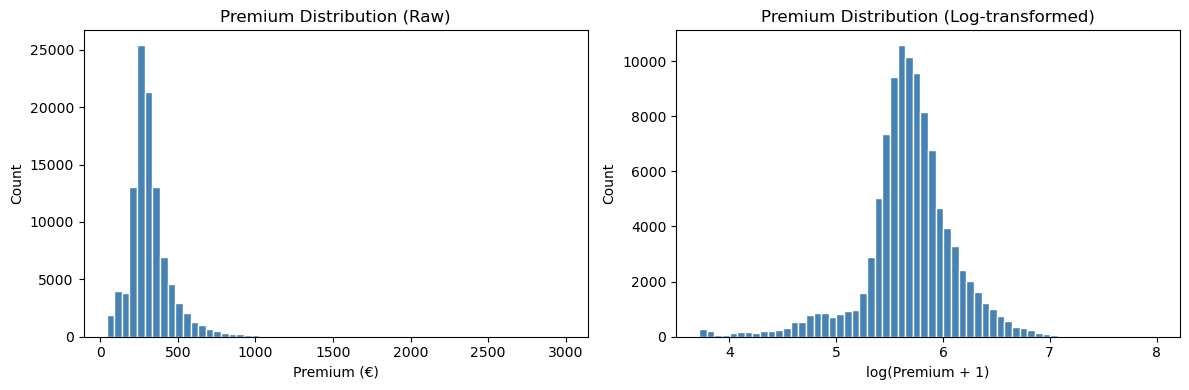

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw distribution
axes[0].hist(df_clean['Premium'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Premium Distribution (Raw)')
axes[0].set_xlabel('Premium (€)')
axes[0].set_ylabel('Count')

# Log-transformed
axes[1].hist(np.log1p(df_clean['Premium']), bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Premium Distribution (Log-transformed)')
axes[1].set_xlabel('log(Premium + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Log transformation shows an improved distribution with a less extreme tail. Therefore, we will be utilizing the log-transformed premium distribution as our target dependent variable for regression.

In [8]:
# Premium outlier analysis
q1 = df_clean['Premium'].quantile(0.25)
q3 = df_clean['Premium'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

outliers = df_clean[df_clean['Premium'] > upper_fence]['Premium']

print(f"Q1:           €{q1:.2f}")
print(f"Q3:           €{q3:.2f}")
print(f"IQR:          €{iqr:.2f}")
print(f"Upper fence:  €{upper_fence:.2f}  (Q3 + 1.5×IQR)")
print(f"Outliers:     {len(outliers):,} rows ({len(outliers)/len(df_clean)*100:.1f}% of data)")
print(f"Outlier range: €{outliers.min():.2f} – €{outliers.max():.2f}")
print(f"\nTop 10 highest premiums:")
print(df_clean['Premium'].nlargest(10).reset_index(drop=True).to_string())

Q1:           €244.05
Q3:           €363.26
IQR:          €119.21
Upper fence:  €542.07  (Q3 + 1.5×IQR)
Outliers:     6,435 rows (6.2% of data)
Outlier range: €542.08 – €2993.34

Top 10 highest premiums:
0    2993.34
1    2797.51
2    2596.77
3    2143.86
4    2116.69
5    2116.69
6    2109.66
7    2049.60
8    2007.82
9    1972.48


Conclusion: We definitely need to log-transform these values for feature preparation. Adjusting the column below.

In [9]:
df_clean['Log_premium'] = np.log1p(df_clean['Premium'])
df_clean.head()

,ID,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Cost_claims_year,...,Length,Weight,Is_active,Driver_age,Licence_years,Vehicle_age,Loss_ratio,Claim_occurred,Fuel_diesel,Log_premium
0,1,0,4,1,2,1,0,0,222.52,0.0,...,4.23,190,1,62,42,14,0.0,0,0,5.409501
1,1,0,4,1,2,1,0,0,213.78,0.0,...,4.23,190,1,62,42,14,0.0,0,0,5.369614
2,1,0,4,2,2,1,0,0,214.84,0.0,...,4.23,190,1,62,42,14,0.0,0,0,5.374537
3,1,0,4,2,2,1,0,0,216.99,0.0,...,4.23,190,1,62,42,14,0.0,0,0,5.384449
4,2,0,4,2,2,1,0,1,213.70,0.0,...,4.23,190,1,62,42,14,0.0,0,0,5.369242


### Step 3: Correlation Heatmap

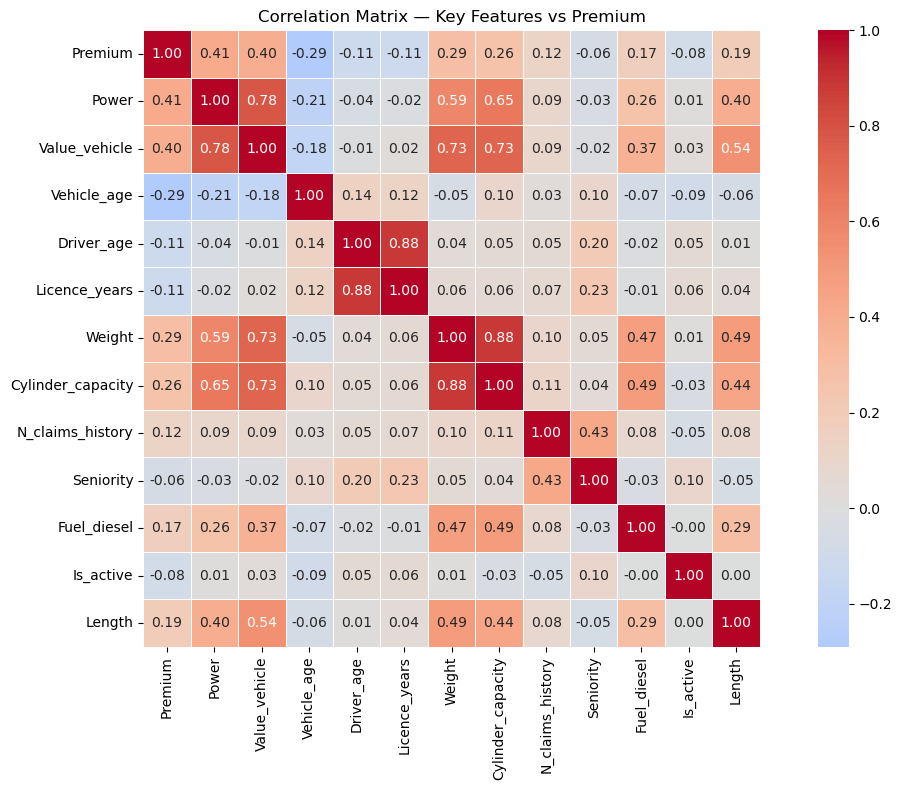

In [10]:
corr_cols = ['Premium', 'Power', 'Value_vehicle', 'Vehicle_age', 'Driver_age',
             'Licence_years', 'Weight', 'Cylinder_capacity', 'N_claims_history',
             'Seniority', 'Fuel_diesel', 'Is_active', 'Length']

corr_matrix = df_clean[corr_cols].corr().round(2)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Key Features vs Premium')
plt.tight_layout()
plt.show()

Correlation between driver's age and mount of time they've had a license is high, which makes sense. Older drivers likely have had their license for longer. Both are likely critical for risk calculation, however, and will be kept.

Another thing to note is the high correlation between vehicle characteristics-- Power, Value_Vehicle, Weight, Length, and Cylinder Capacity.

### Step 4: Segment Comparisons

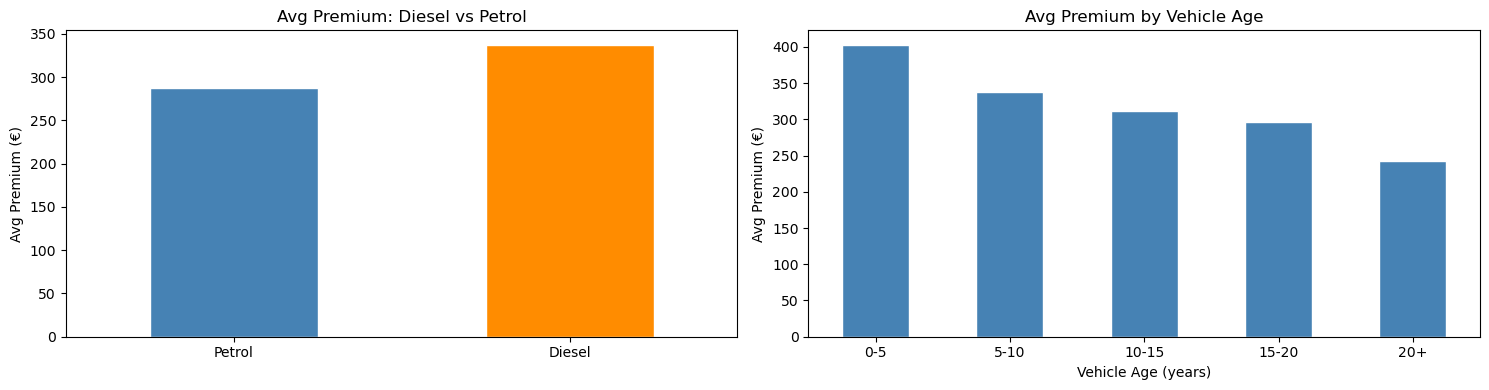

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Premium by fuel type
df_clean.groupby('Fuel_diesel')['Premium'].mean().rename({0: 'Petrol', 1: 'Diesel'}).plot(
    kind='bar', ax=axes[0], color=['steelblue', 'darkorange'], edgecolor='white')
axes[0].set_title('Avg Premium: Diesel vs Petrol')
axes[0].set_xlabel('')
axes[0].set_ylabel('Avg Premium (€)')
axes[0].tick_params(axis='x', rotation=0)

# Premium vs Vehicle age (binned) — use local variable to avoid mutating df_clean
vehicle_age_bin = pd.cut(df_clean['Vehicle_age'], bins=[0, 5, 10, 15, 20, 65],
                         labels=['0-5', '5-10', '10-15', '15-20', '20+'])
df_clean.groupby(vehicle_age_bin, observed=True)['Premium'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Avg Premium by Vehicle Age')
axes[1].set_xlabel('Vehicle Age (years)')
axes[1].set_ylabel('Avg Premium (€)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


These visuals don't play a big roll for us, but it's interesting to see whether there are drastic differences between categories. It makes logical sense that older vehicles would have a lower insurance premium, as they would likely have a lower value.

### Class Imbalance: Claim Occurrence

Before modeling claim occurrence, we must acknowledge a structural imbalance in the
target variable. Only ~18.6% of policy-years result in a claim. A naive model that
always predicts "no claim" would achieve ~81% accuracy while catching zero actual
claimants — a critical failure mode in insurance.

This is flagged here in EDA so the correction is motivated before we reach the
modeling notebooks. Notebooks 2 (MLR) and 3 (RF) each address the imbalance using
`class_weight='balanced'` and report before/after metrics.

=== Claim Occurrence Distribution ===
  No Claim (0):  84,292  (81.2%)
  Claim    (1):  19,499  (18.8%)

  Imbalance ratio: 4.3:1

  A dummy 'always predict no-claim' classifier would achieve:
    Accuracy = 81.2%  |  Recall(claim) = 0%

  → Accuracy is not an appropriate metric for this task.
  → Primary metrics: ROC-AUC, Recall, F1-Score


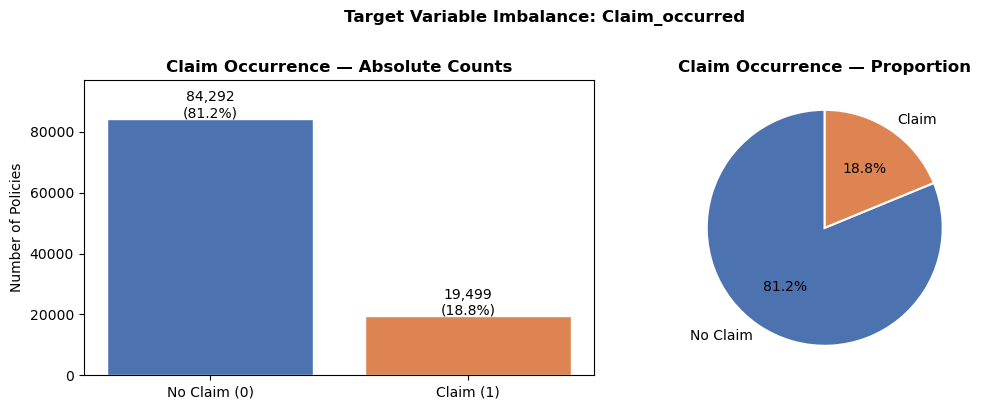

In [12]:
claim_counts = df_clean['Claim_occurred'].value_counts().sort_index()
claim_pct    = df_clean['Claim_occurred'].value_counts(normalize=True).sort_index() * 100

print("=== Claim Occurrence Distribution ===")
print(f"  No Claim (0): {claim_counts[0]:>7,}  ({claim_pct[0]:.1f}%)")
print(f"  Claim    (1): {claim_counts[1]:>7,}  ({claim_pct[1]:.1f}%)")
print(f"\n  Imbalance ratio: {claim_counts[0]/claim_counts[1]:.1f}:1")
print(f"\n  A dummy 'always predict no-claim' classifier would achieve:")
print(f"    Accuracy = {claim_pct[0]:.1f}%  |  Recall(claim) = 0%")
print(f"\n  → Accuracy is not an appropriate metric for this task.")
print(f"  → Primary metrics: ROC-AUC, Recall, F1-Score")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#4C72B0', '#DD8452']

axes[0].bar(['No Claim (0)', 'Claim (1)'], [claim_counts[0], claim_counts[1]],
            color=colors, edgecolor='white')
axes[0].set_title('Claim Occurrence — Absolute Counts', fontweight='bold')
axes[0].set_ylabel('Number of Policies')
for i, (cnt, pct) in enumerate(zip(claim_counts, claim_pct)):
    axes[0].text(i, cnt + 400, f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=10)
axes[0].set_ylim(0, max(claim_counts) * 1.15)

axes[1].pie([claim_pct[0], claim_pct[1]], labels=['No Claim', 'Claim'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Claim Occurrence — Proportion', fontweight='bold')

plt.suptitle('Target Variable Imbalance: Claim_occurred', fontsize=12,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Part III. PCA and Clustering

### Step 1: PCA on Vehicle Specifications

PCA features were selected based on correlation found in the correlation heatmap. It is also logical that the selected features are correlated, as they directly contribute to vehicle power and size classes.

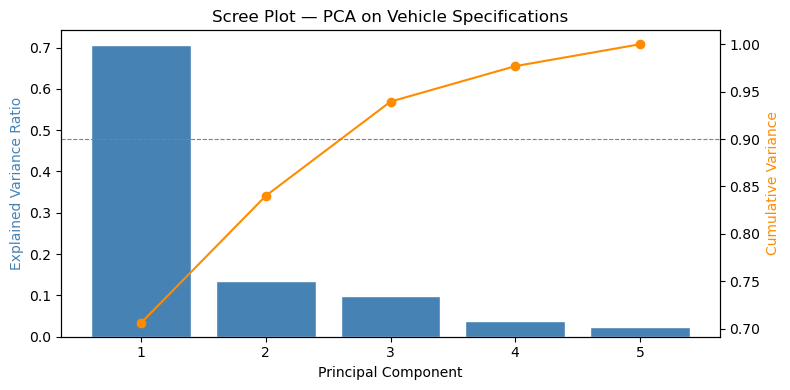

PC1: 0.706 individual  |  0.706 cumulative
PC2: 0.134 individual  |  0.840 cumulative
PC3: 0.099 individual  |  0.940 cumulative
PC4: 0.037 individual  |  0.977 cumulative
PC5: 0.023 individual  |  1.000 cumulative


In [13]:
# PCA input features
pca_cols = ['Power', 'Cylinder_capacity', 'Weight', 'Length', 'Value_vehicle']

# Standardize — PCA is scale-sensitive
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[pca_cols])

# Fit PCA with all components first to evaluate explained variance
pca_full = PCA(n_components=len(pca_cols))
pca_full.fit(X_scaled)

# Scree plot
explained = pca_full.explained_variance_ratio_
cumulative = explained.cumsum()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(range(1, len(explained)+1), explained, color='steelblue',
        edgecolor='white', label='Individual')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio', color='steelblue')
ax1.set_xticks(range(1, len(explained)+1))

ax2 = ax1.twinx()
ax2.plot(range(1, len(explained)+1), cumulative, color='darkorange',
         marker='o', label='Cumulative')
ax2.set_ylabel('Cumulative Variance', color='darkorange')
ax2.axhline(0.90, color='gray', linestyle='--', linewidth=0.8, label='90% threshold')

plt.title('Scree Plot — PCA on Vehicle Specifications')
fig.tight_layout()
plt.show()

for i, (ind, cum) in enumerate(zip(explained, cumulative), 1):
    print(f"PC{i}: {ind:.3f} individual  |  {cum:.3f} cumulative")

PC 2 and 3 are the closest to most viable, but PC 3 results in the inability to plot in 2D. I'm going with PC2 and accepting a 0.16 loss in variance.

### Step 2: Choose n components based on elbow in scree plot

In [14]:
N_COMPONENTS = 2  # 84% variance explained; 2D enables cluster visualization

pca = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by {N_COMPONENTS} components: "
      f"{pca.explained_variance_ratio_.sum():.1%}")
print(f"\nComponent loadings (feature contributions):")
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_cols,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
).round(3)
print(loadings)

Variance explained by 2 components: 84.0%

Component loadings (feature contributions):
                     PC1    PC2
Power              0.438 -0.261
Cylinder_capacity  0.477 -0.244
Weight             0.475 -0.132
Length             0.347  0.923
Value_vehicle      0.485 -0.054


This result tells us that PC1 has a positive correlation with all features-- a powerful, large vehicle. PC2 is mostly driven by length while sacrificing that power and weight-- a long car without much strength.

### Step 3: Elbow Method for K-Means Clustering

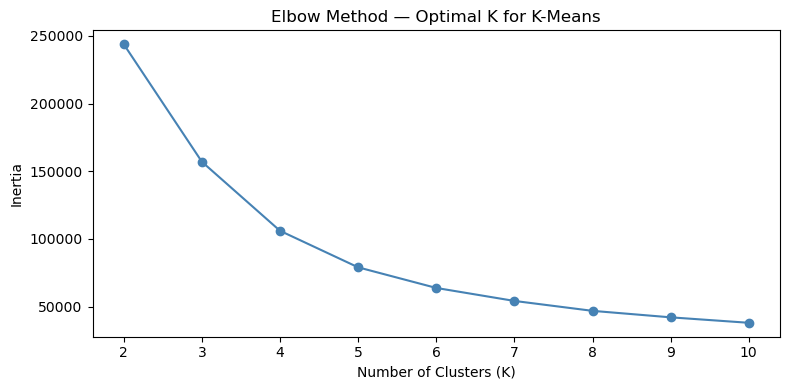

K=2: inertia=243,822.2
K=3: inertia=156,997.2
K=4: inertia=106,019.7
K=5: inertia=79,034.3
K=6: inertia=63,800.4
K=7: inertia=54,211.3
K=8: inertia=46,885.9
K=9: inertia=42,096.0
K=10: inertia=38,059.1


In [15]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal K for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

for k, val in zip(k_range, inertia):
    print(f"K={k}: inertia={val:,.1f}")

Elbow is most prominent at k=4. This means we will have 4 named tiers derived from the clustering algorithm. For the sake of this dataset, we will use string values ["Budget", "Standard", "Premium", "High Performance"]

### Step 4: Fitting K-Means and Assigning Str Risk Tiers

In [16]:
# Fit K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_pca)

# Inspect cluster means on original (unscaled) features to interpret each cluster
cluster_means = df_clean.groupby('Cluster')[pca_cols + ['Premium']].mean().round(1)
print(cluster_means)

         Power  Cylinder_capacity  Weight  Length  Value_vehicle  Premium
Cluster                                                                  
0        105.2             1775.1  1324.5     4.3        20809.8    338.0
1         77.8             1427.9  1024.9     3.9        13199.7    300.1
2         19.6              211.0   139.8     4.2         3517.2    136.8
3        136.7             2422.1  1800.7     4.8        33162.3    390.6


From this we can tell that vehicle power and size scales (from least to greatest) by: 2, 1, 0, 3. Next we'll assign the string labels

In [17]:
tier_map = {
    2: 'Budget',
    1: 'Standard',
    0: 'Premium',
    3: 'High Performance'
}

df_clean['Risk_tier'] = df_clean['Cluster'].map(tier_map)

# Confirm distribution
print(df_clean['Risk_tier'].value_counts())
df_clean = df_clean.reset_index(drop=True)

Risk_tier
Premium             48896
Standard            35747
High Performance    12680
Budget               6468
Name: count, dtype: int64


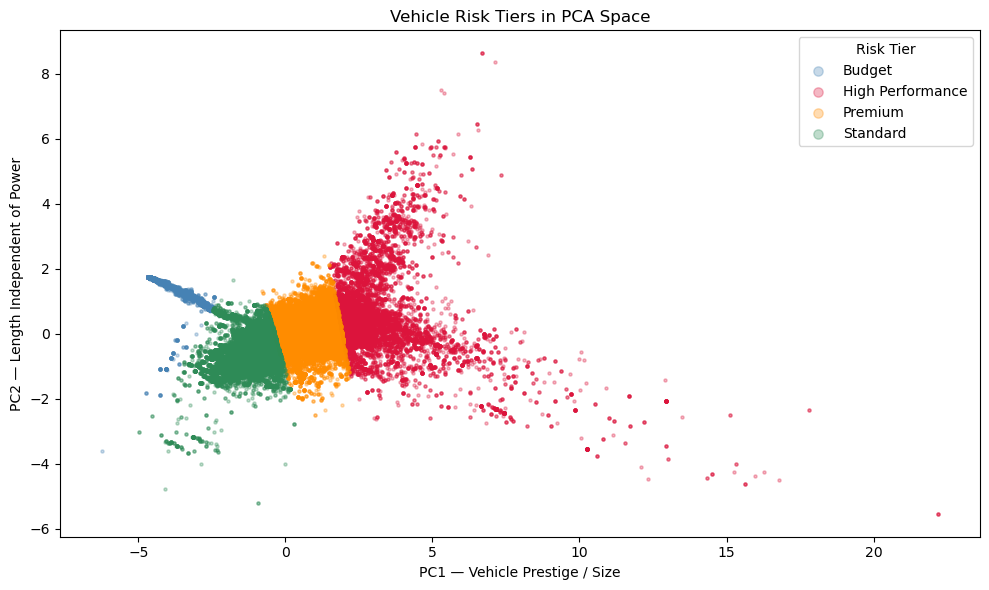

In [18]:
# Visualize clusters in PCA space, colored by risk tier
colors = {
    'Budget': 'steelblue',
    'Standard': 'seagreen',
    'Premium': 'darkorange',
    'High Performance': 'crimson'
}

plt.figure(figsize=(10, 6))
for tier, group in df_clean.groupby('Risk_tier'):
    plt.scatter(
        X_pca[group.index, 0],
        X_pca[group.index, 1],
        label=tier,
        color=colors[tier],
        alpha=0.3,
        s=5
    )

plt.title('Vehicle Risk Tiers in PCA Space')
plt.xlabel('PC1 — Vehicle Prestige / Size')
plt.ylabel('PC2 — Length Independent of Power')
plt.legend(title='Risk Tier', markerscale=3)
plt.tight_layout()
plt.show()


### Step 5: Save PCA etc. settings for future use in modeling and deployment

In [19]:
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
joblib.dump(kmeans, 'kmeans.pkl')
joblib.dump(tier_map, 'tier_map.pkl')

print("Saved: scaler.pkl, pca.pkl, kmeans.pkl, tier_map.pkl")

Saved: scaler.pkl, pca.pkl, kmeans.pkl, tier_map.pkl


In [20]:
# Verify saved objects load correctly
scaler_check  = joblib.load('scaler.pkl')
pca_check     = joblib.load('pca.pkl')
kmeans_check  = joblib.load('kmeans.pkl')
tier_map_check = joblib.load('tier_map.pkl')

print("Tier map:", tier_map_check)
print("PCA components:", pca_check.n_components_)
print("KMeans clusters:", kmeans_check.n_clusters)
print("All objects loaded successfully")

Tier map: {2: 'Budget', 1: 'Standard', 0: 'Premium', 3: 'High Performance'}
PCA components: 2
KMeans clusters: 4
All objects loaded successfully


## Part IV. Shared Modeling Infrastructure

### Step 1: Define feature schema

In [21]:
# Quick sanity check before dropping Lapse
agreement = (df_clean['Lapse'] == (1 - df_clean['Is_active'])).mean()
print(f"Agreement between Lapse and (1 - Is_active): {agreement:.4f}")
print(f"Lapse rate:        {df_clean['Lapse'].mean():.4f}")
print(f"Is_active rate:    {df_clean['Is_active'].mean():.4f}")
print(f"Inferred lapsed:   {(1 - df_clean['Is_active']).mean():.4f}")

Agreement between Lapse and (1 - Is_active): 0.8140
Lapse rate:        0.2205
Is_active rate:    0.6656
Inferred lapsed:   0.3344


In [22]:
# Drop the integer Cluster column-- we keep Risk_tier (the string version) for modeling
df_clean = df_clean.drop(columns=['Cluster'])

# Targets: two parallel prediction tasks
TARGETS = ['Log_premium', 'Claim_occurred']

# Outcome columns that would leak the target (not knowable at underwriting time)
LEAK_COLS = ['Premium', 'Cost_claims_year', 'N_claims_year', 'Loss_ratio']

# Raw vehicle specs replaced by Risk_tier (Option A: PCA-derived tier replaces raw specs)
REPLACED_COLS = ['Power', 'Cylinder_capacity', 'Weight', 'Length', 'Value_vehicle']

# Admin/redundant columns
# - ID: identifier only
# - Year_matriculation: redundant with engineered Vehicle_age
# - Lapse: collinear enough with Is_active that we choose to drop it
ADMIN_COLS = ['ID', 'Year_matriculation', 'Lapse']

# All columns to remove from the feature matrix
EXCLUDE_COLS = TARGETS + LEAK_COLS + REPLACED_COLS + ADMIN_COLS

# Categorical features (will be one-hot encoded)
CATEGORICAL_FEATURES = ['Risk_tier', 'Area', 'Type_risk', 'Distribution_channel', 'Payment']

print(f"df_clean columns: {df_clean.shape[1]}")
print(f"Excluded from features: {len(EXCLUDE_COLS)}")
print(f"Pre-encoding feature count: {df_clean.shape[1] - len(EXCLUDE_COLS)}")

df_clean columns: 32
Excluded from features: 14
Pre-encoding feature count: 18


### Step 2: Build the feature-prep function

In [23]:
def build_model_matrix(df: pd.DataFrame) -> tuple:
    """
    Builds the model-ready feature matrix and both targets.
    
    Drops target columns, leaky outcome columns, redundant admin columns, and
    raw vehicle specs (replaced by Risk_tier per Option A). One-hot encodes
    categorical features with drop_first=True to avoid the dummy variable trap.

    Args:
        df: DataFrame containing engineered features and Risk_tier

    Returns:
        X:     design matrix (DataFrame, no scaling applied)
        y_reg: regression target (Log_premium)
        y_clf: classification target (Claim_occurred)
    """
    # Extract targets
    y_reg = df['Log_premium'].copy()
    y_clf = df['Claim_occurred'].copy()

    # Build feature matrix
    X = df.drop(columns=EXCLUDE_COLS)

    # One-hot encode categoricals (drop_first avoids perfect multicollinearity)
    X = pd.get_dummies(X, columns=CATEGORICAL_FEATURES, drop_first=True, dtype=int)

    return X, y_reg, y_clf

# Run it
X, y_reg, y_clf = build_model_matrix(df_clean)

print(f"X shape:     {X.shape}")
print(f"y_reg shape: {y_reg.shape}")
print(f"y_clf shape: {y_clf.shape}")
X.head(2)

X shape:     (103791, 22)
y_reg shape: (103791,)
y_clf shape: (103791,)


,Seniority,Policies_in_force,Max_policies,Max_products,N_claims_history,R_Claims_history,Second_driver,N_doors,Is_active,Driver_age,...,Fuel_diesel,Risk_tier_High Performance,Risk_tier_Premium,Risk_tier_Standard,Area_1,Type_risk_2,Type_risk_3,Type_risk_4,Distribution_channel_1,Payment_1
0,4,1,2,1,0,0.0,0,0,1,62,...,0,0,0,0,0,0,0,0,0,0
1,4,1,2,1,0,0.0,0,0,1,62,...,0,0,0,0,0,0,0,0,0,0


### Step 3: Master train/test split to maintain consistency across model approaches

In [24]:
# 80/20 split, stratified on claim occurrence so test set has the same claim rate as train
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# Save the indices so RF (h2) and LLM (h3) use the EXACT same test set
# This is what makes the three-model comparison apples-to-apples
split_indices = {
    'train_idx': X_train.index.tolist(),
    'test_idx': X_test.index.tolist()
}
joblib.dump(split_indices, 'split_indices.pkl')

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Saved split_indices.pkl for reuse across h1, h2, h3")

Train shape: (83032, 22)
Test shape:  (20759, 22)
Saved split_indices.pkl for reuse across h1, h2, h3


Used 80-20 train/test split consistently across models.

### Step 4: Sanity-check the split to confirm similar distributions

In [25]:
# Confirm train and test distributions are similar for key fields.

train_orig = df_clean.loc[X_train.index]
test_orig  = df_clean.loc[X_test.index]

print("Premium distribution (€):")
print(pd.DataFrame({
    'train': train_orig['Premium'].describe().round(2),
    'test':  test_orig['Premium'].describe().round(2)
}))

# Stratification guarantees the claim rate matches
print(f"\nClaim rate:")
print(f"  train: {y_train_clf.mean():.4f}")
print(f"  test:  {y_test_clf.mean():.4f}   <- should match train (stratified)")

# verify Premium and Risk_tier
print("\nRisk_tier distribution (%):")
print(pd.DataFrame({
    'train': (train_orig['Risk_tier'].value_counts(normalize=True) * 100).round(2),
    'test':  (test_orig['Risk_tier'].value_counts(normalize=True) * 100).round(2)
}))

Premium distribution (€):
          train      test
count  83032.00  20759.00
mean     318.93    318.45
std      139.38    142.67
min       40.14     40.20
25%      244.39    242.87
50%      294.09    293.54
75%      363.37    362.80
max     2797.51   2993.34

Claim rate:
  train: 0.1879
  test:  0.1879   <- should match train (stratified)

Risk_tier distribution (%):
                  train   test
Risk_tier                     
Premium           47.16  46.89
Standard          34.39  34.65
High Performance  12.20  12.28
Budget             6.25   6.18


The above tests tell us that we have a train / test split that are viably random, due to the data being similar in each set.

## Exporting needed data for future steps

In [26]:
# Saving now:
#   model_inputs.pkl  — train/test splits + feature schema constants
#   df_clean.pkl      — readable DataFrame for LLM prompt construction (Notebook 4)

model_inputs = {
    # Feature matrices (encoded, ready for sklearn)
    'X_train':     X_train,
    'X_test':      X_test,
    # Regression targets (Log_premium)
    'y_train_reg': y_train_reg,
    'y_test_reg':  y_test_reg,
    # Classification targets (Claim_occurred)
    'y_train_clf': y_train_clf,
    'y_test_clf':  y_test_clf,
    # Feature schema — needed to rebuild the matrix for new policies in the agent demo
    'EXCLUDE_COLS':         EXCLUDE_COLS,
    'CATEGORICAL_FEATURES': CATEGORICAL_FEATURES,
    'TARGETS':              TARGETS,
    'LEAK_COLS':            LEAK_COLS,
    'REPLACED_COLS':        REPLACED_COLS,
    'ADMIN_COLS':           ADMIN_COLS,
}
joblib.dump(model_inputs, 'model_inputs.pkl')

# df_clean uses original readable column values (Risk_tier strings, raw Premium, etc.)
# The LLM notebook needs this — NOT the one-hot encoded X matrix — to build prompts
df_clean.to_pickle('df_clean.pkl')

print("✓ model_inputs.pkl  — X_train/X_test, y splits, feature schema")
print("✓ df_clean.pkl      — cleaned DataFrame for LLM prompt construction")
print()
print("Full artifact inventory:")
print("  model_inputs.pkl   (this cell)")
print("  df_clean.pkl       (this cell)")
print("  split_indices.pkl  (Part IV, Step 3)")
print("  scaler.pkl         (Part III, Step 5)")
print("  pca.pkl            (Part III, Step 5)")
print("  kmeans.pkl         (Part III, Step 5)")
print("  tier_map.pkl       (Part III, Step 5)")
print()
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features ({len(X_train.columns)}): {list(X_train.columns)}")

✓ model_inputs.pkl  — X_train/X_test, y splits, feature schema
✓ df_clean.pkl      — cleaned DataFrame for LLM prompt construction

Full artifact inventory:
  model_inputs.pkl   (this cell)
  df_clean.pkl       (this cell)
  split_indices.pkl  (Part IV, Step 3)
  scaler.pkl         (Part III, Step 5)
  pca.pkl            (Part III, Step 5)
  kmeans.pkl         (Part III, Step 5)
  tier_map.pkl       (Part III, Step 5)

X_train: (83032, 22)  |  X_test: (20759, 22)
Features (22): ['Seniority', 'Policies_in_force', 'Max_policies', 'Max_products', 'N_claims_history', 'R_Claims_history', 'Second_driver', 'N_doors', 'Is_active', 'Driver_age', 'Licence_years', 'Vehicle_age', 'Fuel_diesel', 'Risk_tier_High Performance', 'Risk_tier_Premium', 'Risk_tier_Standard', 'Area_1', 'Type_risk_2', 'Type_risk_3', 'Type_risk_4', 'Distribution_channel_1', 'Payment_1']
